## Final Project 

#### Titanic Survival Analysis

#### Description: Perform exploratory data analysis (EDA) on the Titanic dataset to understand the factors that influenced passenger survival
#### Create visualizations to represent survival rates by class, gender, age, etc.


#### Dataset: Titanic Dataset 

#### Tools/Libraries: Pandas for data manipulation, Matplotlib and Seaborn for visualizations.



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape

(891, 12)

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
# filling missing values 

df["Age"] = df["Age"].fillna(df["Age"].median()) # filled with median because median gives middle values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) # filled with mode because embarked is in non numeric form so median is no suitable
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [9]:
df.duplicated().sum()

np.int64(0)

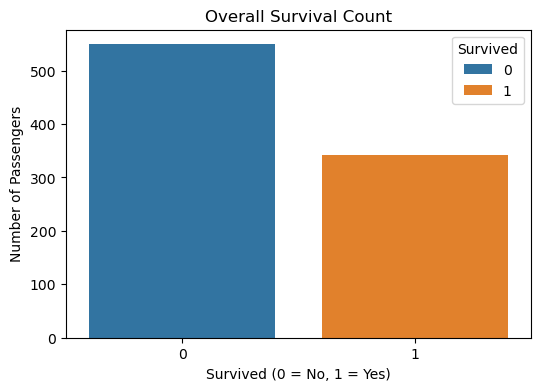

Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
# count plot showing how many Titanic passengers survived and how many did not survive.
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Survived",hue="Survived")
plt.title("Overall Survival Count") 
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers") 
plt.show()
print(df["Survived"].value_counts())

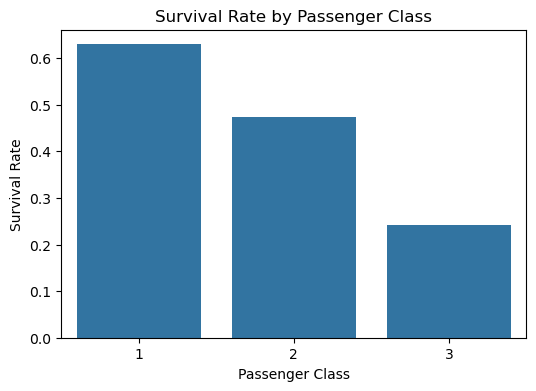

In [9]:
#Survival Rate by passenger class
plt.figure(figsize = (6,4))
sns.barplot(data=df,x="Pclass",y="Survived",errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

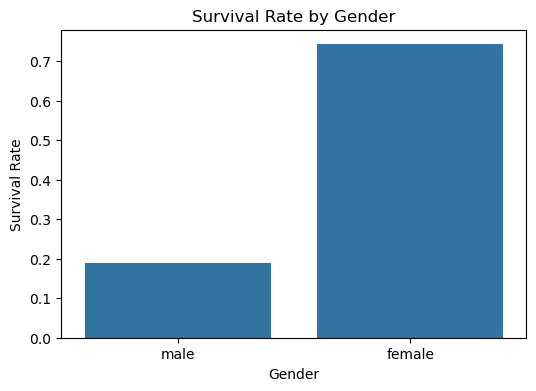

In [10]:
# Survival Rate by Gender
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Sex",y="Survived",errorbar=None)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

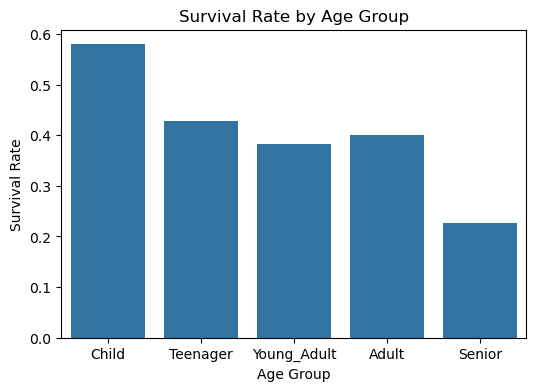

In [4]:
# Survival Rate by Age group 
# we have to divide age in group
df["Age_Group"]=pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100] , #bins create boundaries or range like here 0-12 = Child,12-18=Teenager...etc
    labels=["Child","Teenager","Young_Adult","Adult","Senior"]
)
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Age_Group",y="Survived",errorbar=None)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()


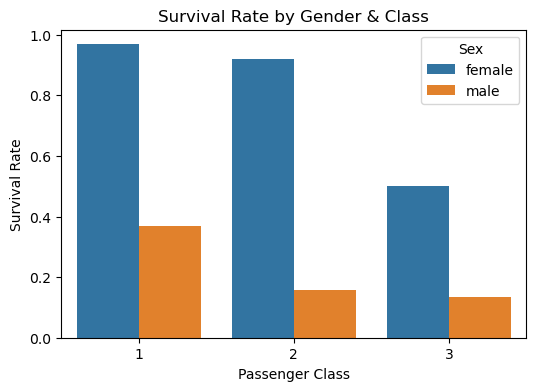

Pclass  Sex   
1       female    91
        male      45
2       female    70
        male      17
3       female    72
        male      47
Name: Survived, dtype: int64

In [6]:
# Survival rate by gender and class
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Pclass",
            y="Survived",
            hue="Sex",errorbar=None) # hue use different colors to represent different categories.
plt.title("Survival Rate by Gender & Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()
df.groupby(["Pclass","Sex"])["Survived"].sum()

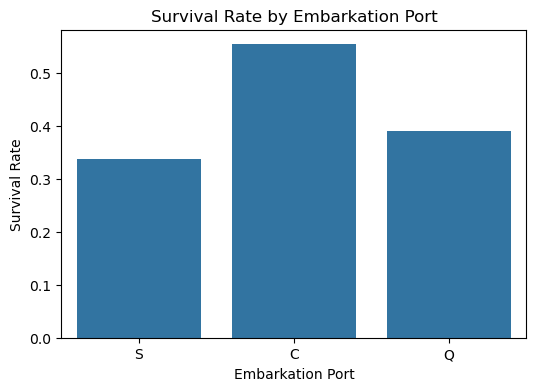

Embarked
C     93
Q     30
S    217
Name: Survived, dtype: int64

In [9]:
# Survival rate by embarkation port
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Embarked",y="Survived",errorbar=None)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")
plt.show()
df.groupby(["Embarked"])["Survived"].sum()

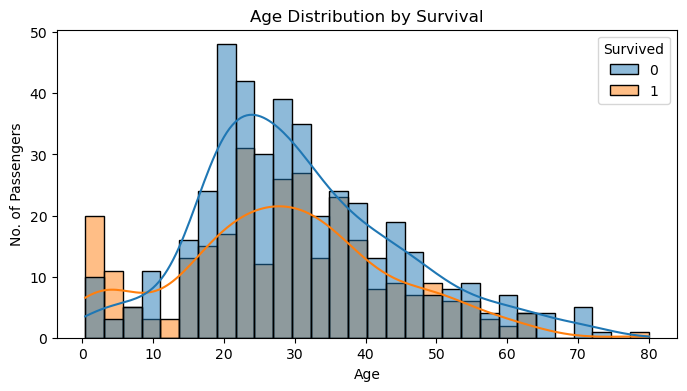

In [12]:
# Age Distribution By Survival
plt.figure(figsize=(8,4))
sns.histplot(data=df,x="Age",hue="Survived",bins=30,kde=True) # kde=True Creates A curve showing overal distribution
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("No. of Passengers")
plt.show()

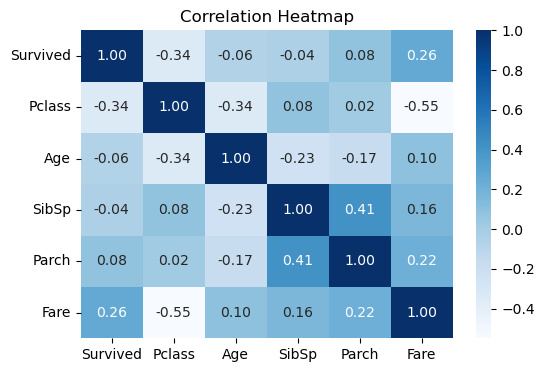

In [20]:
# Correlation heatmap
plt.figure(figsize=(6,4))
numeric_data=df[
    ["Survived","Pclass","Age","SibSp","Parch","Fare"]]  # numeric_data is a new DataFrame containing only 
# the numerical columns from our Titanic dataset.
sns.heatmap(numeric_data.corr(), # Correlation measures the relationship between numerical values.
           annot = True, # annot means annotation it shows actual correlation
           cmap="Blues", # cmap is colormap
            fmt=".2f" # shows format it shows numbers with 2 digits after the decimal point.
            )
plt.title("Correlation Heatmap")
plt.show()
